# Comparing Longstaff–Schwartz and Reinforcement Learning for American Option Pricing

This project compares two methods for pricing an American put option: Longstaff–Schwartz Monte Carlo (LSMC) and Least-Squares Policy Iteration (LSPI).

Both methods are tested on the same simulated stock-price paths under a geometric Brownian motion model and compared against a Cox–Ross–Rubinstein binomial tree benchmark.

The main aim is to see which method gives the most accurate price as the number of simulated paths increases.

## 2. Model Setup

The American put option is priced using the following parameters:

$$
S_0 = 100,\qquad
K = 100,\qquad
r = 0.05,\qquad
q = 0,\qquad
\sigma = 0.20,\qquad
T = 1
$$

where \(S_0\) is the initial stock price, \(K\) is the strike price, \(r\) is the risk-free rate, \(q\) is the dividend yield, \(\sigma\) is the volatility, and \(T\) is the time to maturity.

The option has 50 equally spaced exercise intervals:

$$
M = 50
$$

so the time step is

$$
\Delta t = \frac{T}{M}
= \frac{1}{50}
= 0.02.
$$

In [4]:
#The american put option paramaters
#50 exercise dates
S0 = 100
K = 100
r = 0.05
q = 0
sigma = 0.20
T = 1

print(S0, K, r, q, sigma, T)

M = 50
dt = T/M
print(dt)

100 100 0.05 0 0.2 1
0.02


## 3. Geometric Brownian Motion Simulation

Under the risk-neutral measure, the stock price is assumed to follow geometric Brownian motion:

$$
dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t
$$

Rather than using an Euler approximation, the stock paths are simulated using the exact GBM solution:

$$
S_{t+\Delta t}
=
S_t
\exp\left[
\left(r-q-\frac{1}{2}\sigma^2\right)\Delta t
+
\sigma \Delta W_t
\right]
$$

where

$$
\Delta W_t \sim N(0,\Delta t).
$$

This gives simulated stock-price paths over the 50 exercise intervals, which are then used by both LSMC and LSPI.

In [5]:
def simulate_gbm_paths(S0, r, q, sigma, T, M, n_paths, seed=None):
    dt = T / M
    rng = np.random.default_rng(seed)

    #Brownian motion increments: dW ~ N(0, dt)
    dW = np.sqrt(dt) * rng.standard_normal((n_paths, M))

    #Exact GBM log-price increments
    dlogS = (r - q - 0.5 * sigma**2) * dt + sigma * dW

    logS = np.cumsum(dlogS, axis=1)

    #add the initial stock price at time = 0
    paths = np.empty((n_paths, M + 1))
    paths[:, 0] = S0
    paths[:, 1:] = S0 * np.exp(logS)

    return paths

### Simulating the Stock Price Paths

I first generate 10,000 simulated stock-price paths using the GBM function above. With 50 exercise intervals, each path contains 51 stock prices including the initial value at \(t=0\).

The expected output shape is therefore:

$$
(10000,\ 51)
$$

In [6]:
#Generate 10,000 paths of GBM process
n_paths = 10000
seed = 42

paths = simulate_gbm_paths(S0, r, q, sigma, T, M, n_paths, seed)

#Check the dimensions
print(paths.shape) # Should be (10000, 51)

(10000, 51)


### Checking the Simulation

Before using the simulated paths, I run a few basic checks to make sure the GBM simulation is behaving as expected.

All paths should start at the initial stock price \(S_0\), stock prices should remain positive, and the simulated average terminal price should be close to the theoretical risk-neutral expectation:

$$
\mathbb{E}[S_T] = S_0 e^{(r-q)T}.
$$

In [7]:
#Basic GBM sanity checks
all_start_at_s0 = np.all(paths[:, 0] == S0)# Basic GBM sanity checks
all_start_at_S0 = np.all(paths[:, 0] == S0)
all_positive = np.all(paths > 0)

simulated_mean_ST = np.mean(paths[:, -1])
theoretical_mean_ST = S0 * np.exp((r - q) * T)

print("All paths start at S0:", all_start_at_S0)
print("All prices are positive:", all_positive)
print("Simulated E[S_T]:", simulated_mean_ST)
print("Theoretical E[S_T]:", theoretical_mean_ST)

All paths start at S0: True
All prices are positive: True
Simulated E[S_T]: 105.0294739664813
Theoretical E[S_T]: 105.12710963760242


### Visualising the Simulated Paths

To get a quick visual check of the simulation, I plot 10 of the generated GBM paths over the one-year period. The paths show the different possible movements of the stock price produced by the model.

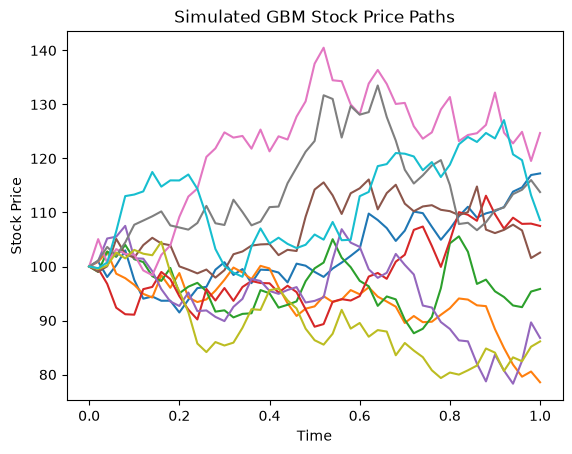

In [ ]:
# Plot 10 simulated GBM paths
time = np.linspace(0, T, M + 1)

for i in range(10):
    plt.plot(time, paths[i])

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Simulated GBM Stock Price Paths")
plt.show()

## 4. Binomial Tree Benchmark

To measure the accuracy of LSMC and LSPI, I use a Cox-Ross-Rubinstein binomial tree as the benchmark price.

For each small tree step, the up and down movements are

$$
u = e^{\sigma \sqrt{\Delta t_{\text{tree}}}},
\qquad
d = \frac{1}{u}
$$

and the risk-neutral probability of an upward move is

$$
p =
\frac{
e^{(r-q)\Delta t_{\text{tree}}} - d
}{
u-d
}.
$$

The option value is then calculated backwards through the tree using

$$
V_t =
e^{-r\Delta t_{\text{tree}}}
\left[
pV_{t+\Delta t}^{u}
+
(1-p)V_{t+\Delta t}^{d}
\right].
$$

At each allowed exercise date, the holder compares the value of continuing with the immediate put payoff

$$
(K-S_t)^+.
$$

Therefore,

$$
V_t
=
\max
\left[
(K-S_t)^+,\,
\text{continuation value}
\right].
$$

The tree uses a much finer time grid than the Monte Carlo methods, while restricting exercise to the same 50 exercise dates. This gives a high-accuracy benchmark while keeping the comparison consistent.

In [9]:
def american_put_binomial(S0, K, r, q, sigma, T, M, N_tree):
    if N_tree % M != 0:
        raise ValueError("N_tree must be divisible by M")

    dt_tree = T / N_tree
    u = np.exp(sigma * np.sqrt(dt_tree))
    d = 1 / u

    # Risk-neutral probability and discount factor
    p = (np.exp((r - q) * dt_tree) - d) / (u - d)
    discount = np.exp(-r * dt_tree)

    exercise_gap = N_tree // M

    # Put payoff at maturity
    j = np.arange(N_tree + 1)
    S = S0 * u**(2 * j - N_tree)
    V = np.maximum(K - S, 0)

    # Work backwards through the tree
    for n in range(N_tree - 1, -1, -1):
        V = discount * (p * V[1:] + (1 - p) * V[:-1])

        if n % exercise_gap == 0:
            j = np.arange(n + 1)
            S = S0 * u**(2 * j - n)
            exercise = np.maximum(K - S, 0)
            V = np.maximum(V, exercise)

    return V[0]

### Calculating the Benchmark Price

I use a 5,000-step binomial tree to calculate the benchmark price. Since 5,000 is divisible by the 50 exercise intervals, the tree can restrict early exercise to the same dates used by LSMC and LSPI.

This keeps the comparison consistent across all three methods.

In [10]:
# Calculate the binomial benchmark
N_tree = 5000

V_binomial = american_put_binomial(
    S0, K, r, q, sigma, T, M, N_tree
)

print("Binomial benchmark:", V_binomial)

Binomial benchmark: 6.078525385846821


### Checking Binomial Tree Convergence

Before using the 5,000-step tree as the benchmark, I check that the calculated option price has stabilised as the number of tree steps increases.

If the prices change only slightly at larger tree sizes, this gives confidence that the benchmark is sufficiently accurate for comparing LSMC and LSPI.


In [11]:
# Check convergence of the binomial benchmark
tree_sizes = [500, 1000, 2500, 5000]

for N in tree_sizes:
    price = american_put_binomial(
        S0, K, r, q, sigma, T, M, N
    )
    print(N, "steps:", price)

500 steps: 6.077323397827316
1000 steps: 6.078056021954221
2500 steps: 6.078371664439777
5000 steps: 6.078525385846821


## 5. Longstaff-Schwartz Monte Carlo

The first pricing method is Longstaff-Schwartz Monte Carlo (LSMC). The main idea is to work backwards through the exercise dates and estimate the value of continuing to hold the option.

For an American put, the immediate exercise payoff is

$$
(K-S_t)^+.
$$

At each exercise date, I only use paths where the option is in the money. The continuation value is then estimated using a least-squares regression.

I normalise the stock price by the strike,

$$
x = \frac{S_t}{K},
$$

and use the quadratic basis

$$
1,\qquad x,\qquad x^2.
$$

The continuation value is approximated as

$$
\hat{C}(x)
=
\beta_0
+
\beta_1 x
+
\beta_2 x^2.
$$

The option is exercised whenever the immediate payoff is at least as large as the estimated continuation value:

$$
(K-S_t)^+
\geq
\hat{C}(S_t).
$$

The algorithm works backwards through time and stores the fitted regression coefficients at each exercise date. These coefficients define the stopping policy used later on a separate set of simulated paths.

In [12]:
def fit_lsmc_policy(paths, K, r, T):
    n_paths, n_dates = paths.shape
    M = n_dates - 1
    dt = T / M

    # Start with the payoff at maturity
    cashflow = np.maximum(K - paths[:, -1], 0)
    exercise_time = np.full(n_paths, M)

    beta = np.zeros((M + 1, 3))

    # Work backwards through the exercise dates
    for m in range(M - 1, 0, -1):
        S = paths[:, m]
        payoff = np.maximum(K - S, 0)
        itm = payoff > 0

        x = S[itm] / K

        Y = cashflow[itm] * np.exp(
            -r * (exercise_time[itm] - m) * dt
        )

        X = np.column_stack((np.ones(len(x)), x, x**2))

        beta[m] = np.linalg.lstsq(X, Y, rcond=None)[0]

        continuation = X @ beta[m]
        exercise = payoff[itm] >= continuation

        idx = np.where(itm)[0][exercise]

        cashflow[idx] = payoff[idx]
        exercise_time[idx] = m

    return beta

### Fitting the LSMC Policy

I now fit the Longstaff-Schwartz stopping policy using the simulated GBM paths.

The regression coefficients are estimated separately at each exercise date. Since the basis contains three terms,

$$
1,\qquad x,\qquad x^2,
$$

the coefficient matrix has three fitted values for each time step.

As a quick check, I also inspect the coefficients halfway through the option's life at

$$
t = 0.5.
$$


In [13]:
# Fit the LSMC stopping policy
beta_lsmc = fit_lsmc_policy(
    paths, K, r, T
)

print("Coefficient matrix shape:", beta_lsmc.shape)
print("Example coefficients at t = 0.5:", beta_lsmc[25])

Coefficient matrix shape: (51, 3)
Example coefficients at t = 0.5: [ 176.96951255 -294.22951021  122.002633  ]


### Pricing with the Fitted LSMC Policy

After fitting the stopping policy, I apply it to a set of simulated paths to estimate the option price.

At each exercise date, the model compares the immediate payoff

$$
(K-S_t)^+
$$

with the continuation value estimated from the fitted regression coefficients.

If exercise is optimal, the payoff is discounted back to time 0 using

$$
e^{-rt}.
$$

Paths that are never exercised early receive the terminal payoff at maturity. The final LSMC price is the average discounted payoff across all simulated paths.


In [14]:
def price_lsmc_policy(paths, beta, K, r, T):
    n_paths, n_dates = paths.shape
    M = n_dates - 1
    dt = T / M

    alive = np.ones(n_paths, dtype=bool)
    discounted_payoff = np.zeros(n_paths)

    # Apply the learned stopping policy
    for m in range(1, M):
        S = paths[:, m]
        payoff = np.maximum(K - S, 0)

        itm = alive & (payoff > 0)

        if np.any(itm):
            x = S[itm] / K
            X = np.column_stack((np.ones(len(x)), x, x**2))

            continuation = X @ beta[m]
            exercise = payoff[itm] >= continuation

            idx = np.where(itm)[0][exercise]

            discounted_payoff[idx] = payoff[idx] * np.exp(-r * m * dt)
            alive[idx] = False

    # Payoff at maturity for paths still alive
    discounted_payoff[alive] = (
        np.maximum(K - paths[alive, -1], 0) * np.exp(-r * T)
    )

    return np.mean(discounted_payoff)

### Evaluating the LSMC Price

To avoid evaluating the model on the same paths used to fit the stopping policy, I generate a new independent set of 10,000 GBM paths using a different random seed.

The fitted LSMC policy is then applied to these new paths to produce an out-of-sample option price.

I compare this estimate with the binomial benchmark using the absolute pricing error

$$
\text{Error}_{\text{LSMC}}
=
\left|
V_{\text{LSMC}} - V_{\text{Binomial}}
\right|.
$$

In [15]:
# Generate new paths and evaluate the learned LSMC policy
evaluation_paths = simulate_gbm_paths(
    S0, r, q, sigma, T, M, n_paths=10000, seed=43
)

V_lsmc = price_lsmc_policy(
    evaluation_paths, beta_lsmc, K, r, T
)

lsmc_error = abs(V_lsmc - V_binomial)

print("LSMC price:", V_lsmc)
print("Binomial benchmark:", V_binomial)
print("Absolute pricing error:", lsmc_error)

LSMC price: 6.140571178737295
Binomial benchmark: 6.078525385846821
Absolute pricing error: 0.06204579289047363


### Checking LSMC with More Simulated Paths

As a quick check, I repeat the LSMC calculation using 50,000 training paths and a separate set of 50,000 evaluation paths.

This gives an indication of how the pricing error changes when the Monte Carlo sample size is increased.

In [16]:
# Check LSMC with 50,000 paths
paths_50k = simulate_gbm_paths(
    S0, r, q, sigma, T, M, n_paths=50000, seed=44
)

beta_lsmc_50k = fit_lsmc_policy(
    paths_50k, K, r, T
)

evaluation_paths_50k = simulate_gbm_paths(
    S0, r, q, sigma, T, M, n_paths=50000, seed=45
)

V_lsmc_50k = price_lsmc_policy(
    evaluation_paths_50k, beta_lsmc_50k, K, r, T
)

print("LSMC price:", V_lsmc_50k)
print("Binomial benchmark:", V_binomial)
print("Absolute pricing error:", abs(V_lsmc_50k - V_binomial))

LSMC price: 6.052124483336506
Binomial benchmark: 6.078525385846821
Absolute pricing error: 0.026400902510315127


## 6. Least-Squares Policy Iteration

The second method is Least-Squares Policy Iteration (LSPI), a reinforcement learning approach to the American option stopping problem.

At each exercise date, the agent has two possible actions:

$$
a = 0 \quad \text{Exercise}
$$

$$
a = 1 \quad \text{Continue}
$$

The state is described using the normalised stock price

$$
x = \frac{S_t}{K}
$$

and normalised time

$$
\tau = \frac{t}{T}.
$$

I use the following six state features:

$$
\psi(\tau,x)
=
\begin{bmatrix}
1 \\
x \\
x^2 \\
\tau \\
\tau x \\
(1-x)^+
\end{bmatrix}.
$$

The final term represents the normalised immediate payoff of the American put.

LSPI approximates the action-value function using a linear model,

$$
Q(s,a) \approx \theta^\top \phi(s,a),
$$

where separate feature blocks are used for the exercise and continue actions.

This gives 12 action features in total: six for exercise and six for continuation.

In [17]:
N_STATE_FEATURES = 6
N_ACTION_FEATURES = 2 * N_STATE_FEATURES

def state_features(tau, x):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    tau = np.full_like(x, tau, dtype=float)

    payoff = np.maximum(1 - x, 0)

    # Linear LSPI state basis
    return np.column_stack((
        np.ones_like(x),
        x,
        x**2,
        tau,
        tau * x,
        payoff
    ))


def action_features(tau, x, action):
    psi = state_features(tau, x)
    zeros = np.zeros_like(psi)

    # Action 0 = exercise, Action 1 = continue
    if action == 0:
        return np.hstack((psi, zeros))
    else:
        return np.hstack((zeros, psi))

### Preparing the LSPI State Data

Before fitting LSPI, I convert the simulated stock prices into the normalised variables used by the reinforcement learning model.

The stock price is normalised by the strike:

$$
x_t = \frac{S_t}{K},
$$

while time is scaled between 0 and 1:

$$
\tau_t = \frac{t}{T}.
$$

The immediate exercise reward is also written in normalised form:

$$
R_{\text{exercise}}(x_t)
=
(1-x_t)^+.
$$

This gives the state and reward data needed to train the LSPI policy.

In [18]:
def prepare_lspi_data(paths, K, T):
    n_paths, n_dates = paths.shape
    M = n_dates - 1

    # Normalised state variables
    x = paths / K
    tau = np.linspace(0, 1, M + 1)

    # Normalised exercise payoff
    exercise_reward = np.maximum(1 - x, 0)

    return x, tau, exercise_reward


x_lspi, tau_lspi, exercise_reward_lspi = prepare_lspi_data(
    paths, K, T
)

print("State matrix shape:", x_lspi.shape)
print("Number of time points:", len(tau_lspi))

State matrix shape: (10000, 51)
Number of time points: 51


### Greedy Action Selection

Given a set of LSPI parameters $\theta$, the model estimates the value of both possible actions:

$$
Q_{\text{exercise}}(s)
$$

and

$$
Q_{\text{continue}}(s).
$$

The greedy policy then chooses the action with the higher estimated value.

If

$$
Q_{\text{exercise}}(s) > Q_{\text{continue}}(s),
$$

the option is exercised. Otherwise, the policy continues to hold the option.

I initialise the LSPI parameter vector so that the exercise-action payoff feature starts with weight 1. This gives the model a sensible starting estimate for the known put payoff before policy iteration begins.

In [19]:
def greedy_actions(theta, tau, x):
    phi_exercise = action_features(tau, x, action=0)
    phi_continue = action_features(tau, x, action=1)

    Q_exercise = phi_exercise @ theta
    Q_continue = phi_continue @ theta

    # Exercise only when its estimated value is strictly higher
    return np.where(Q_exercise > Q_continue, 0, 1)


# Initial LSPI parameters
theta = np.zeros(12)
theta[5] = 1.0

actions = greedy_actions(
    theta, tau_lspi[25], x_lspi[:, 25]
)

print("Action vector shape:", actions.shape)
print("Exercise decisions:", np.sum(actions == 0))
print("Continue decisions:", np.sum(actions == 1))

Action vector shape: (10000,)
Exercise decisions: 4567
Continue decisions: 5433


### LSTDQ Policy Evaluation

LSPI evaluates the current policy using Least-Squares Temporal Difference Q-learning (LSTDQ).

The discount factor over one exercise interval is

$$
\gamma = e^{-r\Delta t}.
$$

For each simulated state, the algorithm considers the exercise and continue actions and builds a least-squares system of the form

$$
A\theta = b.
$$

For the exercise action, the reward is the immediate normalised put payoff and the episode ends.

For the continue action, there is no immediate payoff. Instead, the value depends on the discounted estimated value of the next state under the current greedy policy:

$$
Q(s_t,\text{continue})
\approx
\gamma Q(s_{t+1},a^*_{t+1}),
$$

where

$$
a^*_{t+1}
=
\arg\max_a Q(s_{t+1},a).
$$

The matrices $A$ and $b$ collect these relationships across all simulated paths and exercise dates. The updated parameter vector is then found by solving

$$
(A+\lambda I)\theta = b,
$$

where a very small regularisation term is added for numerical stability.

In [20]:
def lstdq_policy_evaluation(x, tau, exercise_reward, theta, r, T, reg=1e-8):
    n_paths, n_dates = x.shape
    M = n_dates - 1
    dt = T / M
    gamma = np.exp(-r * dt)

    A = np.zeros((N_ACTION_FEATURES, N_ACTION_FEATURES))
    b = np.zeros(N_ACTION_FEATURES)
    n_samples = 0

    # Build the LSPI least-squares system
    for m in range(1, M):
        x_m = x[:, m]

        # Exercise action: immediate payoff and termination
        phi_exercise = action_features(tau[m], x_m, action=0)
        A += phi_exercise.T @ phi_exercise
        b += phi_exercise.T @ exercise_reward[:, m]
        n_samples += n_paths

        # Continue action: move to the next state
        phi_continue = action_features(tau[m], x_m, action=1)

        if m == M - 1:
            terminal_payoff = gamma * exercise_reward[:, M]

            A += phi_continue.T @ phi_continue
            b += phi_continue.T @ terminal_payoff

        else:
            x_next = x[:, m + 1]
            next_actions = greedy_actions(theta, tau[m + 1], x_next)

            psi_next = state_features(tau[m + 1], x_next)
            phi_next = np.zeros((n_paths, N_ACTION_FEATURES))

            exercise_next = next_actions == 0

            phi_next[exercise_next, :N_STATE_FEATURES] = psi_next[exercise_next]
            phi_next[~exercise_next, N_STATE_FEATURES:] = psi_next[~exercise_next]

            A += phi_continue.T @ (
                phi_continue - gamma * phi_next
            )

        n_samples += n_paths

    A /= n_samples
    b /= n_samples

    # Solve Aθ = b with a small numerical stabiliser
    theta_new = np.linalg.solve(
        A + reg * np.eye(N_ACTION_FEATURES),
        b
    )

    return theta_new

### LSPI Policy Iteration

The LSPI algorithm alternates between two steps:

1. evaluating the current policy using LSTDQ;
2. improving the policy by choosing the action with the highest estimated $Q$-value.

The parameter vector is initialised using the known exercise payoff feature. At each iteration, a new parameter vector $\theta_{\text{new}}$ is calculated from the LSTDQ system.

To check whether the algorithm has converged, I measure the change in the parameter vector using

$$
\left\|
\theta_{\text{new}}-\theta
\right\|_2.
$$

The iteration stops when this change falls below the tolerance

$$
10^{-6},
$$

or when the maximum number of iterations is reached.

This produces the final LSPI stopping policy used for pricing.


In [21]:
def fit_lspi(x, tau, exercise_reward, r, T, max_iter=20, tol=1e-6, verbose=False):
    theta = np.zeros(N_ACTION_FEATURES)

    # Initialise exercise value using the known put payoff
    theta[N_STATE_FEATURES - 1] = 1.0

    # Alternate policy evaluation and improvement
    for k in range(max_iter):
        theta_new = lstdq_policy_evaluation(
            x, tau, exercise_reward, theta, r, T
        )

        change = np.linalg.norm(theta_new - theta)
        theta = theta_new

        if verbose:
            print(f"Iteration {k + 1}: change = {change:.6f}")

        if change < tol:
            if verbose:
                print("LSPI converged.")
            break

    return theta

### Fitting the Final LSPI Policy

I now fit the LSPI model using the feature representation defined above.

As a quick diagnostic, I inspect the stopping decision at

$$
t = 0.5
$$

for a range of stock prices.

For an American put, lower stock prices should generally make immediate exercise more attractive, while higher stock prices should favour continuation. Looking at the learned decisions therefore gives a useful check on the shape of the stopping policy.

In [22]:
# Refit LSPI with the improved feature basis
theta_lspi = fit_lspi(
    x_lspi,
    tau_lspi,
    exercise_reward_lspi,
    r,
    T
)

# Check the stopping boundary at t = 0.5
S_grid = np.arange(60, 101, 5)
actions = greedy_actions(
    theta_lspi, 0.5, S_grid / K
)

for S, action in zip(S_grid, actions):
    decision = "Exercise" if action == 0 else "Continue"
    print(f"S = {S:3.0f}  ->  {decision}")

S =  60  ->  Exercise
S =  65  ->  Exercise
S =  70  ->  Exercise
S =  75  ->  Continue
S =  80  ->  Continue
S =  85  ->  Continue
S =  90  ->  Continue
S =  95  ->  Continue
S = 100  ->  Continue


### Pricing with the Fitted LSPI Policy

Once the LSPI policy has been fitted, I apply it to simulated stock-price paths in the same way as the LSMC stopping policy.

At each exercise date, the policy chooses between exercise and continuation using the learned $Q$-values.

If the policy chooses exercise, the payoff

$$
(K-S_t)^+
$$

is discounted back to time 0 using

$$
e^{-rt}.
$$

Any paths that are not exercised early receive the terminal payoff at maturity.

The LSPI option price is then estimated as the average discounted payoff across all simulated paths.

In [23]:
def price_lspi_policy(paths, theta, K, r, T):
    n_paths, n_dates = paths.shape
    M = n_dates - 1
    dt = T / M

    alive = np.ones(n_paths, dtype=bool)
    discounted_payoff = np.zeros(n_paths)

    # Apply the learned LSPI stopping policy
    for m in range(1, M):
        idx_alive = np.where(alive)[0]
        S = paths[idx_alive, m]
        x = S / K
        tau = m / M

        actions = greedy_actions(theta, tau, x)
        exercise = actions == 0

        idx_exercise = idx_alive[exercise]

        payoff = np.maximum(K - paths[idx_exercise, m], 0)

        discounted_payoff[idx_exercise] = (
            payoff * np.exp(-r * m * dt)
        )

        alive[idx_exercise] = False

    # Payoff at maturity for paths still alive
    discounted_payoff[alive] = (
        np.maximum(K - paths[alive, -1], 0) * np.exp(-r * T)
    )

    return np.mean(discounted_payoff)


### Initial LSPI Pricing Comparison

I now evaluate the fitted LSPI policy on the same independent set of evaluation paths used for LSMC.

Using the same paths makes the comparison fair because both methods are exposed to exactly the same simulated market outcomes.

The LSPI absolute pricing error is

$$
\text{Error}_{\text{LSPI}}
=
\left|
V_{\text{LSPI}} - V_{\text{Binomial}}
\right|.
$$

I then compare this directly with the LSMC price and error from the same evaluation sample.

In [24]:
# Price the LSPI policy on the same evaluation paths used for LSMC
V_lspi = price_lspi_policy(
    evaluation_paths, theta_lspi, K, r, T
)

# Compare LSPI with the binomial benchmark
lspi_error = abs(V_lspi - V_binomial)

print("LSPI price:", V_lspi)
print("Binomial benchmark:", V_binomial)
print("Absolute pricing error:", lspi_error)

# Direct comparison with LSMC on the same paths
print("LSMC price:", V_lsmc)
print("LSMC error:", lsmc_error)

LSPI price: 5.850114109091266
Binomial benchmark: 6.078525385846821
Absolute pricing error: 0.22841127675555484
LSMC price: 6.140571178737295
LSMC error: 0.06204579289047363


### Inspecting the Learned Exercise Boundary

To better understand the LSPI stopping policy, I inspect its decisions halfway through the option's life at

$$
t = 0.5.
$$

For a range of stock prices, the policy chooses either exercise or continuation.

For an American put, I would expect exercise to become more attractive as the stock price falls. This gives a simple way to check whether the learned stopping rule behaves sensibly.

In [25]:
# Inspect the LSPI stopping rule at t = 0.5
S_grid = np.arange(60, 121, 5)
x_grid = S_grid / K
tau = 0.5

actions = greedy_actions(theta_lspi, tau, x_grid)

# Convert numerical actions into readable decisions
decisions = np.where(actions == 0, "Exercise", "Continue")

for S, decision in zip(S_grid, decisions):
    print(f"S = {S:3.0f}  ->  {decision}")

S =  60  ->  Exercise
S =  65  ->  Exercise
S =  70  ->  Exercise
S =  75  ->  Continue
S =  80  ->  Continue
S =  85  ->  Continue
S =  90  ->  Continue
S =  95  ->  Continue
S = 100  ->  Continue
S = 105  ->  Continue
S = 110  ->  Continue
S = 115  ->  Continue
S = 120  ->  Continue


### Inspecting LSPI Action Values

To see why the LSPI policy chooses exercise or continuation, I inspect the estimated action values at

$$
t = 0.5.
$$

For each stock price, the model calculates

$$
Q_{\text{exercise}}
$$

and

$$
Q_{\text{continue}}.
$$

The policy exercises when

$$
Q_{\text{exercise}} > Q_{\text{continue}},
$$

and continues otherwise.

Looking at these values helps show where the learned stopping boundary comes from and how close the two actions are around the decision region.

In [26]:
# Inspect LSPI action values at t = 0.5
S_grid = np.arange(60, 101, 5)
x_grid = S_grid / K
tau = 0.5

phi_exercise = action_features(tau, x_grid, action=0)
phi_continue = action_features(tau, x_grid, action=1)

Q_exercise = phi_exercise @ theta_lspi
Q_continue = phi_continue @ theta_lspi

for S, Q_E, Q_C in zip(S_grid, Q_exercise, Q_continue):
    decision = "Exercise" if Q_E > Q_C else "Continue"
    print(
        f"S = {S:3.0f} | "
        f"Q(E) = {Q_E:.4f} | "
        f"Q(C) = {Q_C:.4f} | "
        f"{decision}"
    )

S =  60 | Q(E) = 0.4000 | Q(C) = 0.3991 | Exercise
S =  65 | Q(E) = 0.3500 | Q(C) = 0.3474 | Exercise
S =  70 | Q(E) = 0.3000 | Q(C) = 0.2979 | Exercise
S =  75 | Q(E) = 0.2500 | Q(C) = 0.2507 | Continue
S =  80 | Q(E) = 0.2000 | Q(C) = 0.2057 | Continue
S =  85 | Q(E) = 0.1500 | Q(C) = 0.1629 | Continue
S =  90 | Q(E) = 0.1000 | Q(C) = 0.1224 | Continue
S =  95 | Q(E) = 0.0500 | Q(C) = 0.0841 | Continue
S = 100 | Q(E) = 0.0000 | Q(C) = 0.0481 | Continue


### Checking LSPI with More Training Paths

I also fit LSPI using 50,000 training paths to see whether increasing the amount of training data changes the learned stopping rule.

The stopping decisions are again inspected at

$$
t = 0.5
$$

across a range of stock prices.

If the exercise boundary remains similar despite using many more paths, this suggests that the remaining error may come from the chosen linear function approximation rather than simply from Monte Carlo noise.

In [27]:
# Prepare the 50,000 training paths for LSPI
x_lspi_50k, tau_lspi_50k, exercise_reward_lspi_50k = prepare_lspi_data(
    paths_50k, K, T
)

# Fit LSPI with the larger training sample
theta_lspi_50k = fit_lspi(
    x_lspi_50k,
    tau_lspi_50k,
    exercise_reward_lspi_50k,
    r,
    T
)

# Inspect the stopping rule halfway through the year
S_grid = np.arange(60, 101, 5)
actions_50k = greedy_actions(
    theta_lspi_50k, 0.5, S_grid / K
)

for S, action in zip(S_grid, actions_50k):
    decision = "Exercise" if action == 0 else "Continue"
    print(f"S = {S:3.0f}  ->  {decision}")

S =  60  ->  Exercise
S =  65  ->  Exercise
S =  70  ->  Exercise
S =  75  ->  Continue
S =  80  ->  Continue
S =  85  ->  Continue
S =  90  ->  Continue
S =  95  ->  Continue
S = 100  ->  Continue


### Comparing Both Methods with 50,000 Paths

I now evaluate the 50,000-path LSPI policy on the same 50,000 evaluation paths used for the LSMC model.

Using the same evaluation paths keeps the comparison consistent between the two methods.

For each method, I compare the estimated option price with the binomial benchmark using

$$
\text{Absolute Error}
=
\left|
V_{\text{method}} - V_{\text{Binomial}}
\right|.
$$

This gives a larger-sample comparison before moving on to the full repeated experiment across several path sizes.

In [28]:
# Evaluate the 50,000-path LSPI policy
V_lspi_50k = price_lspi_policy(
    evaluation_paths_50k,
    theta_lspi_50k,
    K,
    r,
    T
)

lspi_error_50k = abs(V_lspi_50k - V_binomial)

# Compare both methods on the same 50,000 evaluation paths
print("LSPI price:", V_lspi_50k)
print("LSPI error:", lspi_error_50k)
print("LSMC price:", V_lsmc_50k)
print("LSMC error:", abs(V_lsmc_50k - V_binomial))
print("Binomial benchmark:", V_binomial)

LSPI price: 5.862718529544054
LSPI error: 0.21580685630276708
LSMC price: 6.052124483336506
LSMC error: 0.026400902510315127
Binomial benchmark: 6.078525385846821


### Comparing the Learned Policy with the Binomial Exercise Boundary

As an additional check, I calculate the exercise boundary implied by the binomial tree at

$$
t = 0.5.
$$

The exercise boundary is the highest stock price at which immediate exercise is still optimal.

For an American put, exercise is optimal when

$$
(K-S_t)^+
\geq
\text{Continuation Value}.
$$

Comparing this boundary with the LSPI stopping rule helps show whether the reinforcement learning policy is exercising too early or too late relative to the binomial benchmark.


In [29]:
# Find the binomial-tree exercise boundary at t = 0.5
target_m = 25
target_n = target_m * (N_tree // M)

dt_tree = T / N_tree
u = np.exp(sigma * np.sqrt(dt_tree))
d = 1 / u
p = (np.exp((r - q) * dt_tree) - d) / (u - d)
discount = np.exp(-r * dt_tree)

# Start from maturity and work backwards to t = 0.5
j = np.arange(N_tree + 1)
S = S0 * u**(2 * j - N_tree)
V = np.maximum(K - S, 0)

for n in range(N_tree - 1, target_n - 1, -1):
    continuation = discount * (p * V[1:] + (1 - p) * V[:-1])

    if n % (N_tree // M) == 0:
        j = np.arange(n + 1)
        S = S0 * u**(2 * j - n)
        exercise = np.maximum(K - S, 0)

        if n == target_n:
            exercise_now = (exercise > 0) & (exercise >= continuation)
            boundary = np.max(S[exercise_now])

        V = np.maximum(exercise, continuation)
    else:
        V = continuation

print("Binomial exercise boundary at t = 0.5:", boundary)

Binomial exercise boundary at t = 0.5: 84.87006269953741


## 7. Experimental Design

To compare LSMC and LSPI fairly, I use the same training paths for both methods and then evaluate both fitted policies on a separate shared set of paths.

For each experiment:

1. A training sample of GBM paths is generated.
2. LSMC is fitted using these paths.
3. LSPI is fitted using the same paths.
4. A new independent evaluation sample is generated.
5. Both stopping policies are evaluated on this same evaluation sample.
6. Their absolute pricing errors are measured relative to the binomial benchmark.

Using shared training and evaluation samples helps reduce unnecessary differences caused by random simulation noise.

For each method, the pricing error is

$$
\text{Error}
=
\left|
V_{\text{method}} - V_{\text{Binomial}}
\right|.
$$

In [30]:
def run_experiment(n_paths, seed):
    # Generate one shared training sample
    training_paths = simulate_gbm_paths(
        S0, r, q, sigma, T, M, n_paths, seed
    )

    # Fit Longstaff-Schwartz
    beta = fit_lsmc_policy(
        training_paths, K, r, T
    )

    # Fit LSPI on the same training paths
    x, tau, exercise_reward = prepare_lspi_data(
        training_paths, K, T
    )

    theta = fit_lspi(
        x, tau, exercise_reward, r, T
    )

    # Generate a separate shared evaluation sample
    evaluation_paths = simulate_gbm_paths(
        S0, r, q, sigma, T, M, n_paths, seed + 100000
    )

    # Price both learned stopping policies
    V_lsmc = price_lsmc_policy(
        evaluation_paths, beta, K, r, T
    )

    V_lspi = price_lspi_policy(
        evaluation_paths, theta, K, r, T
    )

    # Measure error relative to the binomial benchmark
    error_lsmc = abs(V_lsmc - V_binomial)
    error_lspi = abs(V_lspi - V_binomial)

    return V_lsmc, error_lsmc, V_lspi, error_lspi

### Testing the Full Experiment

Before running the full set of repeated experiments, I test the complete comparison once using 10,000 simulated paths.

This checks that the full pipeline works correctly: both methods are fitted on the same training sample, evaluated on the same independent test sample, and compared with the same binomial benchmark.

This single run is only a test of the experimental setup. The final conclusions are based on repeated experiments across several different path sizes.

In [31]:
# Test one complete LSMC vs LSPI experiment
V_lsmc_test, error_lsmc_test, V_lspi_test, error_lspi_test = run_experiment(
    n_paths=10000,
    seed=1
)

print("LSMC price:", V_lsmc_test)
print("LSMC error:", error_lsmc_test)
print("LSPI price:", V_lspi_test)
print("LSPI error:", error_lspi_test)
print("Binomial benchmark:", V_binomial)

LSMC price: 6.035507776042325
LSMC error: 0.04301760980449654
LSPI price: 5.752860428017815
LSPI error: 0.32566495782900606
Binomial benchmark: 6.078525385846821


### Repeated Experiments Across Different Sample Sizes

To see how both methods behave as the amount of simulated data increases, I repeat the full LSMC vs LSPI experiment across a range of Monte Carlo sample sizes.

The path counts used are:

$$
500,\;1000,\;5000,\;10000,\;25000,\;50000,\;100000.
$$

For each sample size, I run the experiment 20 times using different random seeds.

In every repetition:

1. A new GBM training sample is generated.
2. LSMC is fitted on that sample.
3. LSPI is fitted on the same sample.
4. A separate evaluation sample is generated.
5. Both fitted policies are evaluated on the same evaluation paths.
6. The estimated prices are compared with the fixed binomial benchmark.

The absolute pricing error for each method is

$$
\text{Error}
=
\left|
V_{\text{method}} - V_{\text{Binomial}}
\right|.
$$

Running 20 repetitions at each path count makes the comparison more reliable than using a single random seed, since Monte Carlo estimates will naturally vary from one simulation to another.

The smaller path counts show how both methods behave when relatively little simulation data is available, while the larger path counts help show whether the pricing estimates improve and stabilise as the sample size increases.

In total, this gives

$$
7 \times 20 = 140
$$

separate LSMC vs LSPI experiments.

The same experimental setup is kept fixed throughout so that the main thing changing between groups is the number of simulated paths.

In [32]:
# Run 20 repetitions with 500 paths
results_500 = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=500,
        seed=seed
    )

    results_500.append({
        "paths": 500,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_500 = pd.DataFrame(results_500)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20


In [33]:
# Summarise the 500-path repetitions
summary_500 = results_500[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_500)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    5.880704    0.392376    5.687324    0.519180
std     0.458520    0.298950    0.529201    0.396752


In [34]:
# Run 20 repetitions with 1,000 paths
results_1k = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=1000,
        seed=seed
    )

    results_1k.append({
        "paths": 1000,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_1k = pd.DataFrame(results_1k)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20


In [35]:
# Summarise the 1,000-path repetitions
summary_1k = results_1k[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_1k)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    5.964386    0.272186    5.668970    0.437517
std     0.293392    0.147677    0.361431    0.325117


In [36]:
# Run 20 repetitions with 5,000 paths
results_5k = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=5000,
        seed=seed
    )

    results_5k.append({
        "paths": 5000,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_5k = pd.DataFrame(results_5k)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20


In [37]:
# Summarise the 5,000-path repetitions
summary_5k = results_5k[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_5k)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    6.012314    0.111704    5.768866    0.309660
std     0.122077    0.079894    0.135928    0.135928


In [38]:
# Run 20 repetitions with 10,000 paths
results_10k = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=10000,
        seed=seed
    )

    results_10k.append({
        "paths": 10000,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_10k = pd.DataFrame(results_10k)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20


In [39]:
# Summarise the 20 repetitions
summary_10k = results_10k[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_10k)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    6.025764    0.066910    5.780067    0.298458
std     0.070236    0.056132    0.093803    0.093803


In [40]:
# Rerun 25,000 paths for all 20 repetitions
results_25k = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=25000,
        seed=seed
    )

    results_25k.append({
        "paths": 25000,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_25k = pd.DataFrame(results_25k)

print("Final shape:", results_25k.shape)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20
Final shape: (20, 6)


In [41]:
# Summarise the 25,000-path repetitions
summary_25k = results_25k[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_25k)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    6.041375    0.045998    5.792407    0.286119
std     0.043506    0.033442    0.055826    0.055826


In [42]:
# Run 20 repetitions with 50,000 paths
results_50k = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=50000,
        seed=seed
    )

    results_50k.append({
        "paths": 50000,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_50k = pd.DataFrame(results_50k)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20


In [43]:
# Summarise the 50,000-path repetitions
summary_50k = results_50k[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_50k)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    6.046810    0.034452    5.795619    0.282906
std     0.028207    0.024597    0.037555    0.037555


In [44]:
# Run 20 repetitions with 100,000 paths
results_100k = []

for seed in range(1, 21):
    V_lsmc, error_lsmc, V_lspi, error_lspi = run_experiment(
        n_paths=100000,
        seed=seed
    )

    results_100k.append({
        "paths": 100000,
        "seed": seed,
        "LSMC_price": V_lsmc,
        "LSMC_error": error_lsmc,
        "LSPI_price": V_lspi,
        "LSPI_error": error_lspi
    })

    print(f"Completed repetition {seed}/20")

results_100k = pd.DataFrame(results_100k)

Completed repetition 1/20
Completed repetition 2/20
Completed repetition 3/20
Completed repetition 4/20
Completed repetition 5/20
Completed repetition 6/20
Completed repetition 7/20
Completed repetition 8/20
Completed repetition 9/20
Completed repetition 10/20
Completed repetition 11/20
Completed repetition 12/20
Completed repetition 13/20
Completed repetition 14/20
Completed repetition 15/20
Completed repetition 16/20
Completed repetition 17/20
Completed repetition 18/20
Completed repetition 19/20
Completed repetition 20/20


In [45]:
# Summarise the 20 repetitions
summary_100k = results_100k[[
    "LSMC_price",
    "LSMC_error",
    "LSPI_price",
    "LSPI_error"
]].agg(["mean", "std"])

print(summary_100k)

      LSMC_price  LSMC_error  LSPI_price  LSPI_error
mean    6.052838    0.025687    5.802402    0.276124
std     0.014998    0.014998    0.018577    0.018577


## 8. Combining and Summarising the Results

After running the repeated experiments, I combine the results into a single table so that the performance of LSMC and LSPI can be compared across the different path counts.

For each sample size, I calculate the mean estimated option price and the mean absolute pricing error over the repeated runs.

The mean pricing error is

$$
\overline{\text{Error}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
V_i - V_{\text{Binomial}}
\right|,
$$

where $N$ is the number of repetitions.

This makes it easier to compare the overall behaviour of the two methods rather than relying on the result from a single random seed.

The fixed binomial benchmark is also included in the summary table for reference.

In [46]:
# Combine all experimental results
all_results = pd.concat(
    [results_10k, results_50k, results_100k],
    ignore_index=True
)

# Calculate mean prices and errors for each sample size
final_table = all_results.groupby("paths").agg(
    LSMC_price=("LSMC_price", "mean"),
    LSMC_error=("LSMC_error", "mean"),
    LSPI_price=("LSPI_price", "mean"),
    LSPI_error=("LSPI_error", "mean")
).reset_index()

# Add the fixed binomial benchmark
final_table.insert(1, "Binomial_benchmark", V_binomial)

print(final_table.round(4))

    paths  Binomial_benchmark  LSMC_price  LSMC_error  LSPI_price  LSPI_error
0   10000              6.0785      6.0258      0.0669      5.7801      0.2985
1   50000              6.0785      6.0468      0.0345      5.7956      0.2829
2  100000              6.0785      6.0528      0.0257      5.8024      0.2761


## 9. Visualising the Results

### Monte Carlo Stock-Price Simulation

Before comparing the pricing methods, I visualise the GBM simulation used throughout the experiment.

The figure shows a sample of individual simulated stock-price paths together with the mean simulated path and the central 90% range of the simulation.

The shaded region represents the interval between the 5th and 95th percentiles at each point in time. The strike price

$$
K = 100
$$

is also shown for reference.

This gives a visual picture of the uncertainty in the underlying stock-price process that both LSMC and LSPI use when learning their stopping policies.

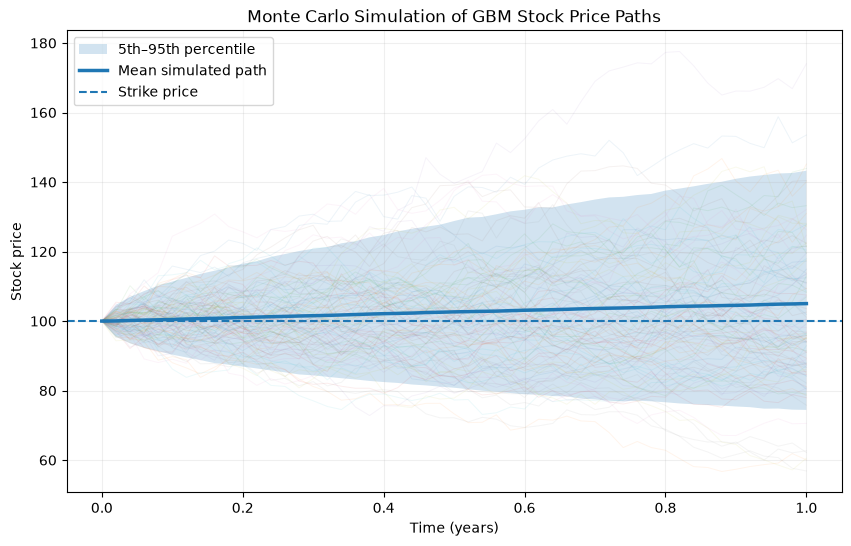

In [47]:
# Visualise the Monte Carlo stock-price simulation
time = np.linspace(0, T, M + 1)

mean_path = np.mean(paths, axis=0)
lower_band = np.percentile(paths, 5, axis=0)
upper_band = np.percentile(paths, 95, axis=0)

plt.figure(figsize=(10, 6))

# Show a sample of individual simulated paths
for i in range(100):
    plt.plot(time, paths[i], alpha=0.08, linewidth=0.7)

# Show the central 90% simulation range
plt.fill_between(
    time,
    lower_band,
    upper_band,
    alpha=0.2,
    label="5th–95th percentile"
)

# Mean simulated stock path
plt.plot(
    time,
    mean_path,
    linewidth=2.5,
    label="Mean simulated path"
)

# Strike price
plt.axhline(
    K,
    linestyle="--",
    linewidth=1.5,
    label="Strike price"
)

plt.xlabel("Time (years)")
plt.ylabel("Stock price")
plt.title("Monte Carlo Simulation of GBM Stock Price Paths")
plt.legend()
plt.grid(alpha=0.2)

# Save the Monte Carlo simulation figure
plt.savefig(
    "figures/gbm_monte_carlo_simulation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Final Summary Table

I now combine the results from all seven sample sizes and calculate the final summary statistics.

For each path count, I report:

- the mean LSMC price,
- the mean LSPI price,
- the mean absolute pricing error for each method,
- and the standard deviation of the pricing error across the 20 repetitions.

The standard deviation shows how much the pricing error varies between different random simulations at the same sample size.

This makes it possible to compare both the accuracy and the stability of LSMC and LSPI as the number of simulated paths increases.

In [48]:
# Combine results from all sample sizes
all_results = pd.concat([
    results_500,
    results_1k,
    results_5k,
    results_10k,
    results_25k,
    results_50k,
    results_100k
], ignore_index=True)

# Create the final summary table
final_table = all_results.groupby("paths").agg(
    LSMC_price=("LSMC_price", "mean"),
    LSMC_error=("LSMC_error", "mean"),
    LSMC_error_std=("LSMC_error", "std"),
    LSPI_price=("LSPI_price", "mean"),
    LSPI_error=("LSPI_error", "mean"),
    LSPI_error_std=("LSPI_error", "std")
).reset_index()

# Add the fixed binomial benchmark
final_table.insert(1, "Binomial_benchmark", V_binomial)

print(final_table.round(4))

    paths  Binomial_benchmark  LSMC_price  LSMC_error  LSMC_error_std  \
0     500              6.0785      5.8807      0.3924          0.2990   
1    1000              6.0785      5.9644      0.2722          0.1477   
2    5000              6.0785      6.0123      0.1117          0.0799   
3   10000              6.0785      6.0258      0.0669          0.0561   
4   25000              6.0785      6.0414      0.0460          0.0334   
5   50000              6.0785      6.0468      0.0345          0.0246   
6  100000              6.0785      6.0528      0.0257          0.0150   

   LSPI_price  LSPI_error  LSPI_error_std  
0      5.6873      0.5192          0.3968  
1      5.6690      0.4375          0.3251  
2      5.7689      0.3097          0.1359  
3      5.7801      0.2985          0.0938  
4      5.7924      0.2861          0.0558  
5      5.7956      0.2829          0.0376  
6      5.8024      0.2761          0.0186  


### Pricing Accuracy Across Sample Sizes

To compare LSMC and LSPI across the different simulation sizes, I present the results in two related ways.

First, I calculate the mean absolute pricing error as a percentage of the binomial benchmark:

$$
\text{Percentage Error}
=
100 \times
\frac{
\left|V_{\text{method}} - V_{\text{Binomial}}\right|
}{
V_{\text{Binomial}}
}.
$$

I also calculate a 95% confidence interval for the mean percentage error using the 20 repeated experiments:

$$
\bar{x}
\pm
1.96
\frac{s}{\sqrt{20}},
$$

where $\bar{x}$ is the mean percentage error and $s$ is the standard deviation across the repetitions.

This first figure therefore shows how the pricing error changes as the number of simulated paths increases, together with the uncertainty around the estimated mean error.

I then present the same results using an accuracy measure defined as

$$
\text{Accuracy}
=
100
\left(
1 -
\frac{
\left|V_{\text{method}} - V_{\text{Binomial}}\right|
}{
V_{\text{Binomial}}
}
\right).
$$

Under this definition, 100% represents exact agreement with the binomial benchmark.

The accuracy figure provides a more intuitive view of how close each method is to the benchmark, while the percentage-error figure gives the more direct measure of pricing performance.

In [50]:
# Convert absolute pricing errors to percentage errors

final_table["LSMC_pct_error"] = (
    100 * final_table["LSMC_error"] / V_binomial
)

final_table["LSPI_pct_error"] = (
    100 * final_table["LSPI_error"] / V_binomial
)

final_table["LSMC_pct_std"] = (
    100 * final_table["LSMC_error_std"] / V_binomial
)

final_table["LSPI_pct_std"] = (
    100 * final_table["LSPI_error_std"] / V_binomial
)

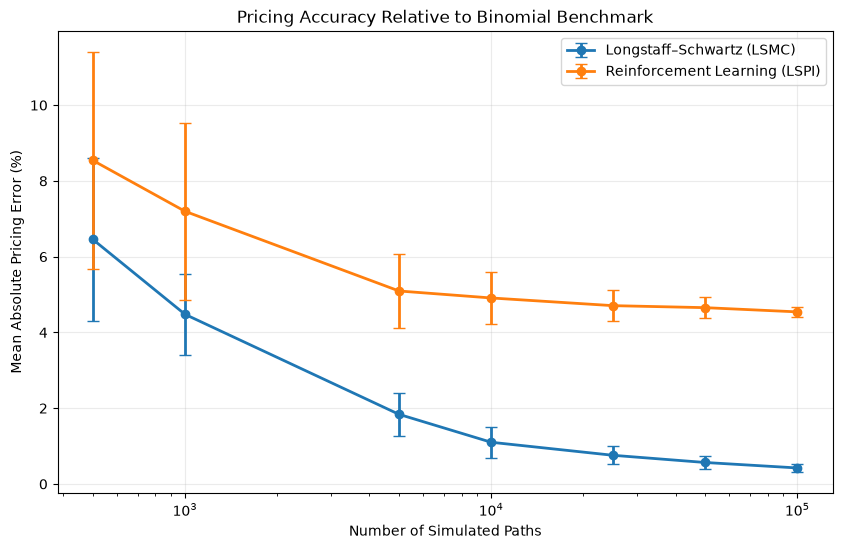

In [51]:
# 95% confidence intervals for mean percentage error
n_reps = 20

LSMC_ci = 1.96 * final_table["LSMC_pct_std"] / np.sqrt(n_reps)
LSPI_ci = 1.96 * final_table["LSPI_pct_std"] / np.sqrt(n_reps)

plt.figure(figsize=(10, 6))

plt.errorbar(
    final_table["paths"],
    final_table["LSMC_pct_error"],
    yerr=LSMC_ci,
    marker="o",
    capsize=4,
    linewidth=2,
    label="Longstaff–Schwartz (LSMC)"
)

plt.errorbar(
    final_table["paths"],
    final_table["LSPI_pct_error"],
    yerr=LSPI_ci,
    marker="o",
    capsize=4,
    linewidth=2,
    label="Reinforcement Learning (LSPI)"
)

plt.xscale("log")

plt.xlabel("Number of Simulated Paths")
plt.ylabel("Mean Absolute Pricing Error (%)")
plt.title("Pricing Accuracy Relative to Binomial Benchmark")
plt.legend()
plt.grid(alpha=0.25)

# Save the percentage-error figure
plt.savefig(
    "figures/pricing_error_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

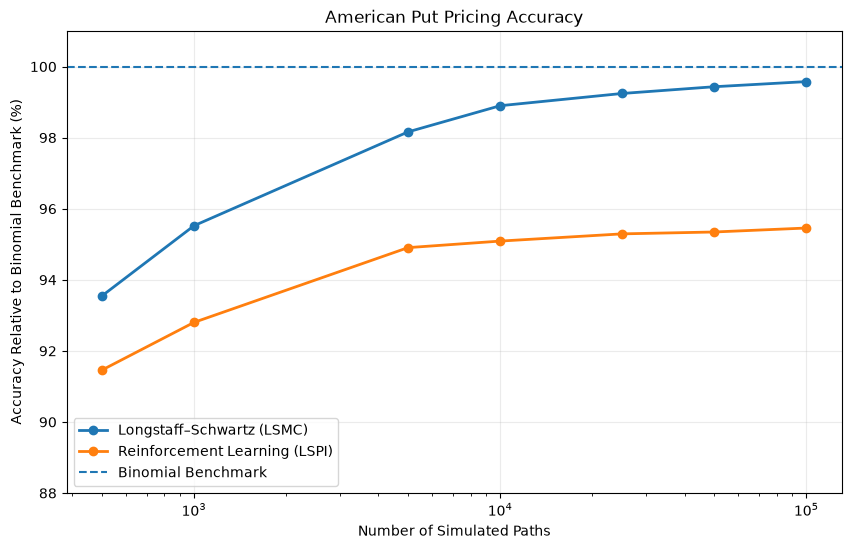

In [ ]:
# Normalise performance relative to the binomial benchmark
final_table["LSMC_accuracy"] = (
    100 * (1 - final_table["LSMC_error"] / V_binomial)
)

final_table["LSPI_accuracy"] = (
    100 * (1 - final_table["LSPI_error"] / V_binomial)
)

plt.figure(figsize=(10, 6))

plt.plot(
    final_table["paths"],
    final_table["LSMC_accuracy"],
    marker="o",
    linewidth=2,
    label="Longstaff–Schwartz (LSMC)"
)

plt.plot(
    final_table["paths"],
    final_table["LSPI_accuracy"],
    marker="o",
    linewidth=2,
    label="Reinforcement Learning (LSPI)"
)

# 100% represents exact agreement with the benchmark
plt.axhline(
    100,
    linestyle="--",
    linewidth=1.5,
    label="Binomial Benchmark"
)

plt.xscale("log")
plt.ylim(88, 101)

plt.xlabel("Number of Simulated Paths")
plt.ylabel("Accuracy Relative to Binomial Benchmark (%)")
plt.title("American Put Pricing Accuracy")
plt.legend()
plt.grid(alpha=0.25)

plt.xlabel("Number of Simulated Paths")
plt.ylabel("Accuracy Relative to Binomial Benchmark (%)")
plt.title("American Put Pricing Accuracy")
plt.legend()
plt.grid(alpha=0.25)

# Save the figure
plt.savefig(
    "figures/pricing_accuracy_lsmc_vs_lspi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# Save raw experimental results
all_results.to_csv("all_results.csv", index=False)

# Save final summary table
final_table.to_csv("final_results_table.csv", index=False)

print("CSV files saved.")

CSV files saved.


In [53]:
import os

# Create the figures folder if it does not already exist
os.makedirs("figures", exist_ok=True)

print("Figures folder ready.")

Figures folder ready.


In [54]:
import os

# Create results folder
os.makedirs("results", exist_ok=True)

# Save raw runs and final summary table
all_results.to_csv("results/all_results.csv", index=False)
final_table.to_csv("results/final_results_table.csv", index=False)

print("Results saved.")

Results saved.
